In [1]:
import pandas as pd
import numpy as np
import os.path as op
import seaborn as sns
import matplotlib.pyplot as plt
import os
from scipy.stats import normaltest, ttest_ind, mannwhitneyu
alpha = 0.05

bids_folder = '/Users/mrenke/data/ds-dnumrisk'
phenotype_folder = '/Users/mrenke/data/ds-dnumrisk/derivatives/phenotype'

groupList =  pd.read_csv(op.join(bids_folder, 'group_mapping.csv'), header=0, index_col=0)
groupList['group'] = np.where(groupList['group'] == 0, 'Control', 'Dyscalculic')

plot_folder = op.join(bids_folder, 'plots_and_ims', 'paper_dnumrisk_01')
os.makedirs(plot_folder, exist_ok=True)
sns.set_context('talk')


/Users/mrenke/mambaforge/envs/behav_fit/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [4]:
from numrisk.behavior_magjudge.utils import get_data

df= get_data(bids_folder,  include_var=['group'])
df = df.sort_index() # so first sub is Control, Control will be plotted first;) 

df['group'] = np.where(df['group'] == 0, 'Control', 'Dyscalculic')
df['n1'] = df['n1'].astype(int)
#df.rename(columns={'n1':'Number range'}, inplace=True)


number of subjects found: 66
number of subjects in dataframe: 66
Int64Index([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
            18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
            35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
            52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66],
           dtype='int64', name='subject')


### Raw behavior

In [12]:
# report accuracy and RT in text
import pingouin as pg
df['correct_answer_n2'] = np.where((df['n2'] > df['n1']), True, False)
df['correct'] = np.where((df['correct_answer_n2'] == df['chose_n2']), True, False)

tmp = df.set_index('group', append=True)
tmp = tmp.groupby(['subject','group']).mean().reset_index()

from scipy.stats import ttest_ind, mannwhitneyu, normaltest

for y_var in ['correct', 'rt']:
    ctrl = tmp.loc[tmp['group']=='Control', y_var]
    dys  = tmp.loc[tmp['group']=='Dyscalculic', y_var]

    ctrl_mean, ctrl_sd = ctrl.mean(), ctrl.std()
    dys_mean, dys_sd   = dys.mean(), dys.std()

    pooled = tmp[y_var].dropna()
    _, p_normal = normaltest(pooled)

    if p_normal > alpha:
        stat, pval = ttest_ind(ctrl, dys)
        test = "t"
        stat_label = f"t = {stat:.2f}"
    else:
        stat, pval = mannwhitneyu(ctrl, dys, alternative="two-sided")
        test = "MWU"
        stat_label = f"U = {stat:.0f}"
    #print(stats)
    print(f"{y_var}: Control {tmp.loc[tmp['group']=='Control', y_var].mean():.2f} +- {tmp.loc[tmp['group']=='Control', y_var].std():.2f}, Dyscalculic {tmp.loc[tmp['group']=='Dyscalculic', y_var].mean():.2f} +- {tmp.loc[tmp['group']=='Dyscalculic', y_var].std():.2f})")
    print(f"{stat_label}, p={pval:.3f}")



correct: Control 0.87 +- 0.05, Dyscalculic 0.85 +- 0.07)
U = 654, p=0.164
rt: Control 1.26 +- 0.30, Dyscalculic 1.44 +- 0.42)
U = 392, p=0.051


### Psychometric model

In [5]:
# psychometric

import bambi # behav_fit2_copy
import arviz as az

model_label = 2
target_folder = op.join(bids_folder, f'derivatives/cogmodels_magjudge')
df['x'] = df['log(n2/n1)'] 

#model = bambi.Model('chose_n2 ~ x + x*n1*group + (x*n1|subject)', link='probit', family='bernoulli', data=df.reset_index())
traces = az.from_netcdf( op.join(target_folder, f'probit_model-{model_label}_trace.netcdf'))

Number range: p=0.96375, mean=0.013102677868606508, 95%CI=[-0.00106698  0.02753195]
Slope: p=0.063, mean=-0.5751384399598628, 95%CI=[-1.30818567  0.16105182]


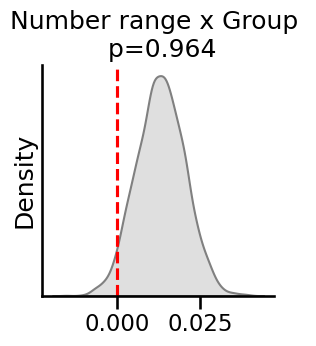

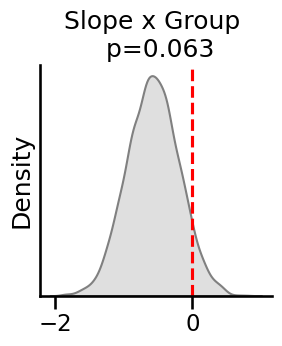

In [7]:
for regressor, name in zip(['n1:group', 'x:group'], ['Number range', 'Slope']):
    temp = traces.posterior[regressor].to_dataframe()
    print(f'{name}: p={np.mean(temp[regressor] > 0)}, mean={np.mean(temp[regressor])}, 95%CI={np.percentile(temp[regressor], [2.5, 97.5])}')

    count_greater_zero = np.round(np.mean(temp[regressor] > 0),3)

    fig, axs = plt.subplots(1,1, figsize=(3,3), sharex=False)
    sns.kdeplot(temp[regressor], ax=axs,legend=False, fill=True, color='grey')
    axs.set(yticks=[],ylabel='Density',xlabel='')
    axs.axvline(x=0, color='r', linestyle='--')
    axs.set_title(f'{name} x Group \n p={count_greater_zero}')
    sns.despine()
    plt.savefig(op.join(plot_folder, f'mag_psychometric_{regressor}.pdf'), bbox_inches='tight')

In [6]:
traces = az.from_netcdf( op.join(target_folder, f'probit_model-{model_label}_trace.netcdf'))
for regressor, name in zip(['n1', 'x'], ['Number range', 'Slope']):
    temp = traces.posterior[regressor].to_dataframe()
    print(f'{name}: p={np.mean(temp[regressor] > 0)}, mean={np.mean(temp[regressor])}, 95%CI={np.percentile(temp[regressor], [2.5, 97.5])}')


Number range: p=1.0, mean=0.03426855188141974, 95%CI=[0.02425891 0.04460338]
Slope: p=1.0, mean=5.328738339794891, 95%CI=[4.78816969 5.8702809 ]


## Cognitive model

In [8]:
# bauer model 
import arviz as az
from bauer.utils.bayes import softplus

target_folder = op.join(bids_folder, f'derivatives/cogmodels_magjudge')
traces =  az.from_netcdf(op.join(target_folder, f'model-3_trace.netcdf'))

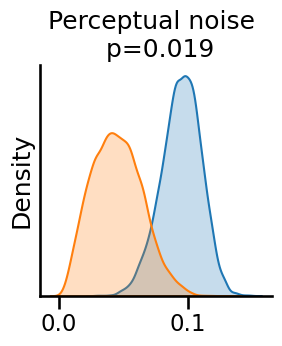

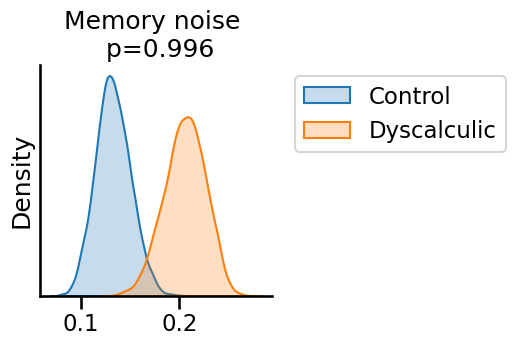

In [4]:
from bauer.utils.bayes import softplus

for noise in ['perceptual', 'memory']:
    tmp = traces.posterior[f'{noise}_noise_sd_mu'].to_dataframe()

    tmp = tmp.unstack(f'{noise}_noise_sd_regressors')
    control = tmp.xs('Intercept', 1, level=1)
    control = control.rename(columns={f'{noise}_noise_sd_mu':'Control'})
    control = softplus(control)
    dys = tmp.xs('Intercept', 1, level=1) + tmp.xs('group', 1, level=1)
    dys = dys.rename(columns={f'{noise}_noise_sd_mu':'Dyscalculic'})
    dys = softplus(dys)
    comb = pd.concat([control, dys], axis=1)
    comb['dif'] = comb['Dyscalculic'] - comb['Control']
    count_greater_zero = np.round(np.mean(comb['dif'] > 0),3)

    plt.figure(figsize=(3,3))
    sns.kdeplot(control, color='blue', fill=True, label='Control',legend=False)
    sns.kdeplot(dys['Dyscalculic'],  color=sns.color_palette()[1], fill=True, label='Dyscalculic')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') if noise== 'memory' else None
    plt.xlabel('')
    plt.yticks([])
    plt.title(f'{noise.capitalize()} noise \n p={count_greater_zero}')
    sns.despine()
    plt.savefig(op.join(plot_folder, f'mag_bauer-3_{noise}_control-dys.pdf'), bbox_inches='tight')

In [ ]:
# Statistics 
from bauer.utils.bayes import softplus

for noise in ['perceptual', 'memory']:
    tmp = traces.posterior[f'{noise}_noise_sd_mu'].to_dataframe()

    tmp = tmp.unstack(f'{noise}_noise_sd_regressors')
    control = tmp.xs('Intercept', 1, level=1)
    control = control.rename(columns={f'{noise}_noise_sd_mu':'Control'})
    control = softplus(control)
    dys = tmp.xs('Intercept', 1, level=1) + tmp.xs('group', 1, level=1)
    dys = dys.rename(columns={f'{noise}_noise_sd_mu':'Dyscalculic'})
    dys = softplus(dys)
    comb = pd.concat([control, dys], axis=1)
    comb['dif'] = comb['Dyscalculic'] - comb['Control']

    print(f'{noise} noise difference: p={np.mean(comb["dif"] > 0)}, mean dif={np.mean(comb["dif"])}, 95%CI={np.percentile(comb["dif"], [2.5, 97.5])}')
    for group in ['Control', 'Dyscalculic']:
        print(f'{group} mean {noise} noise: {np.mean(comb[group])}, 95%CI={np.percentile(comb[group], [2.5, 97.5])}')   

perceptual noise difference: p=0.019166666666666665, mean dif=-0.04952328163016748, 95%CI=[-0.09411248 -0.00231815]
Control mean perceptual noise: 0.09461605588780102, 95%CI=[0.06204503 0.12247037]
Dyscalculic mean perceptual noise: 0.045092774257633535, 95%CI=[0.01146922 0.08530761]
memory noise difference: p=0.9959166666666667, mean dif=0.07275181718781693, 95%CI=[0.02003671 0.12370688]
Control mean memory noise: 0.13264491545610885, 95%CI=[0.0996695 0.1691601]
Dyscalculic mean memory noise: 0.20539673264392577, 95%CI=[0.16258226 0.24300133]


## Neural statistics


In [8]:
df_decode = pd.read_csv(op.join(phenotype_folder, 'decoding_r.csv')).set_index('subject').join(groupList)


In [12]:
df_decode

,r,group
subject,,
1,-0.058083,Control
2,0.206071,Dyscalculic
4,-0.089840,Dyscalculic
5,-0.023735,Control
6,0.062036,Dyscalculic
...,...,...
62,0.305624,Control
63,0.165065,Control
64,0.274937,Control


r - normal distribution (fail to reject H0)
TtestResult(statistic=-0.15137739830488958, pvalue=0.8801617118515485, df=63.0)


/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/Users/mrenke/mambaforge/envs/numrefields/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)


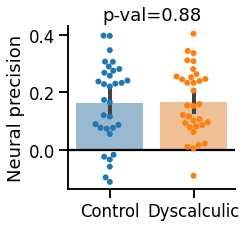

In [21]:
y_var = 'r'

tmp = df_decode.set_index('group', append=True)


figure, axes = plt.subplots(1, 1,figsize = (3,3))
sns.barplot(data=tmp.reset_index(), x ='group',y=y_var, alpha=0.5) # hue='group' ,legend=False
sns.swarmplot(data=tmp.reset_index(),  x ='group', hue='group',y=y_var, size=6,legend=False)
_, pval_normal = normaltest(tmp[y_var])

if pval_normal > alpha:
        print(f'{y_var} - normal distribution (fail to reject H0)')
        stats = ttest_ind(tmp.xs('Control',0,'group')[y_var], tmp.xs('Dyscalculic',0,'group')[y_var], axis=0)
else: # non parametric test
        print(f'{y_var} - not normal distribution (reject H0)')    
        stats = mannwhitneyu(tmp.xs('Control',0,'group')[y_var], tmp.xs('Dyscalculic',0,'group')[y_var], axis=0)
axes.set(title=f'p-val={stats.pvalue:.2f}',
    ylabel='Neural precision', xlabel=None)#,ylim=[0,15])
axes.axhline(0, color='black')#, linestyle='--')
sns.despine()
print(stats)

## Correlation across measures

In [7]:
iq_scores = pd.read_csv(op.join(phenotype_folder, 'iq-scores_ids2.csv')).set_index('subject')
math_stuff = pd.read_csv(op.join(phenotype_folder, 'math_skill&confidence&anxiety-means.csv')).set_index('subject')

df_participants = pd.read_csv(op.join('/Users/mrenke/data/ds-dnumrisk/add_tables','subjects_recruit_scan_scanned-final.csv'), header=0) #, index_col=0
df_participants = df_participants.loc[:,['subject ID', 'age','group','gender']].rename(mapper={'subject ID': 'subject'},axis=1).dropna().astype({'subject': int, 'group': int}).set_index('subject')



In [10]:
df_parietalDANpatch_size = pd.read_csv(op.join(phenotype_folder, 'netsPFM_DANpatches.csv'))
df_parietalDANpatch_size = df_parietalDANpatch_size.rename(columns={'sub_id':'subject'}).set_index(['subject','patch'])
area_measure = 'ind_area' #
df_comb = df_parietalDANpatch_size[area_measure].unstack('patch').join(iq_scores).join(groupList).join(math_stuff['skill_score'])

In [8]:
df_parietalDANpatch_size = pd.read_csv(op.join(phenotype_folder, 'netsPF_DANpatch_sizes.csv'))
df_parietalDANpatch_size = df_parietalDANpatch_size.rename(columns={'sub_id':'subject'}).set_index('subject')#[['DANpatch_size_L','DANpatch_size_R','DANpatch_size_both']]

df_comb = df_parietalDANpatch_size.join(iq_scores).join(math_stuff['skill_score']) # .join(groupList)

In [ ]:
df_npc_pfm_net_area = pd.read_csv(op.join(phenotype_folder,'netsPFM_indArea_NPC.csv'))
df_npc_pfm_net_area = df_npc_pfm_net_area.set_index(['subject','network']).unstack('network')
df_npc_pfm_net_area.columns = [(col[1] + '_' + col[0]) for col in df_npc_pfm_net_area.columns]



df_comb = df_npc_pfm_net_area.join(iq_scores).join(groupList).join(math_stuff['skill_score'])

In [11]:
df_comb.columns


Index(['L_frontal-lateral', 'L_parietal-lateral', 'L_temporal',
       'R_frontal-lateral', 'R_parietal-lateral', 'R_temporal', 'me', 'kn',
       'mean_iq', 'group', 'skill_score'],
      dtype='object')

DANpatch_size_both vs me: r=0.4767824437527625, p= 5.940426482303969e-05
DANpatch_size_both vs kn: r=0.1955053810281985, p= 0.1185865177017069
DANpatch_size_both vs mean_iq: r=0.45447437814160874, p= 0.00014295891782550892


/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_24404/3073959619.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_coeff = cor['r'][0]
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_24404/3073959619.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pval = cor['p-val'][0]
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_24404/3073959619.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_co

Text(0.5, 1.1, 'Correlations: IQ screener ~ DANpatch_size_both-network size in NPC')

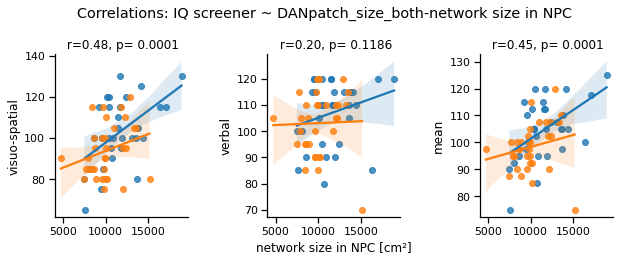

In [101]:
import pingouin

sns.set_context('notebook')

tmp = df_comb.copy()
x_var = 'DANpatch_size_both' #'Visual2_size' # 'Dorsal-attention_size' 
y_var_names = ['visuo-spatial', 'verbal', 'mean']

fig, axs = plt.subplots(1,3, figsize=(10,3))
for i, y_var in enumerate(['me', 'kn', 'mean_iq']):
    cor = pingouin.corr(df_comb[y_var], df_comb[x_var], method = 'pearson') #defautl: two -sided & pearson
    r_coeff = cor['r'][0]
    pval = cor['p-val'][0]
    print(f'{x_var} vs {y_var}: r={r_coeff}, p= {pval}')

    for j, group in enumerate(df_comb['group'].unique()):
        tmp = df_comb[df_comb['group'] == group]
        sns.regplot(x=x_var, y=y_var, data=tmp, color=sns.color_palette()[j], ax=axs[i])

    axs[i].set(title=f' r={r_coeff:.2f}, p= {pval:.4f}', ylabel = y_var_names[i], xlabel=None)

axs[1].set(xlabel='network size in NPC [cm²]')
fig.subplots_adjust(wspace=0.6)
sns.despine()
net_name = x_var #.split('_')[0]
fig.suptitle(f'Correlations: IQ screener ~ {net_name}-network size in NPC', y = 1.1)

In [ ]:
df_comb = df_comb.join(df_participants[['age', 'gender']], on='subject')
df_comb['Gender'] = np.where(df_comb['gender'] == 'm', 1, 0)

In [12]:
df_comb

,L_frontal-lateral,L_parietal-lateral,L_temporal,R_frontal-lateral,R_parietal-lateral,R_temporal,me,kn,mean_iq,group,skill_score
subject,,,,,,,,,,,
1,2893.85500,4814.7020,1832.93100,4589.0044,5347.0740,1433.97610,120.0,105.0,112.5,Control,36.0
2,1004.00916,4049.3140,1082.97000,3094.5550,4547.2610,1418.60520,100.0,95.0,97.5,Dyscalculic,6.0
3,2036.32470,4691.3325,867.63965,2567.5078,5833.8623,1008.51170,115.0,95.0,105.0,Control,29.0
4,3449.32400,6723.5650,1706.00920,2596.2368,5537.7275,1230.28320,110.0,105.0,107.5,Dyscalculic,34.0
6,1412.71400,3985.4292,886.12244,2401.5800,4696.7046,1237.07450,85.0,110.0,97.5,Dyscalculic,3.0
...,...,...,...,...,...,...,...,...,...,...,...
62,4158.46500,7006.6455,1077.35620,3998.1494,7247.5864,2012.28770,125.0,115.0,120.0,Control,28.0
63,3619.72660,4323.7715,947.91296,5801.3926,4969.0940,773.66223,115.0,115.0,115.0,Control,42.0
64,6860.73340,4243.0137,67.70507,5828.0303,5246.6934,815.70807,75.0,120.0,97.5,Control,50.0


In [4]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

df_comb['DANsize'] = df_comb['DANpatch_size_R'] #df_comb['Dorsal-attention_size']
#df_comb['VISsize'] = df_comb['Visual2_size']

dep_var = 'DANsize'
ind_var = 'me'

#formula = f'{dep_var} ~ {ind_var} + group + age + Gender'
formula = f'{dep_var} ~ {ind_var} + group'

result = sm.formula.ols(formula=formula, data=df_comb.reset_index()).fit()

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                DANsize   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.258
Method:                 Least Squares   F-statistic:                     12.13
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           3.57e-05
Time:                        16:41:32   Log-Likelihood:                -549.95
No. Observations:                  65   AIC:                             1106.
Df Residuals:                      62   BIC:                             1112.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             2320.9353   1067.868      2.173      0.034     186.297    4455.574
group[T.Dyscalculic]  -618.1336    305.143     -2.026      0.047   -1228.106      -8.161
me                      37.1837     10.174      3.655      0.001      16.846      57.521
==============================================================================
Omnibus:                        0.817   Durbin-Watson:                   2.198
Prob(Omnibus):                  0.665   Jarque-Bera (JB):                0.588
Skew:                           0.233   Prob(JB):                        0.745
Kurtosis:                       2.987   Cond. No.                         737.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# does hemi size predict better than the other?
df_comb['L_par_lat'] = df_comb['L_parietal-lateral'] 
df_comb['R_par_lat'] = df_comb['R_parietal-lateral'] 

formula = f'me ~  + group  + R_par_lat _ + L_par_lat'

result = sm.formula.ols(formula=formula, data=df_comb.reset_index()).fit()

result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                     me   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.230
Method:                 Least Squares   F-statistic:                     10.56
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           0.000113
Time:                        16:46:11   Log-Likelihood:                -258.70
No. Observations:                  65   AIC:                             523.4
Df Residuals:                      62   BIC:                             529.9
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               73.9070      8.296      8.909      0.000      57.324      90.490
group[T.Dyscalculic]    -4.6028      3.520     -1.307      0.196     -11.640       2.434
R_par_lat                0.0047      0.001      3.652      0.001       0.002       0.007
==============================================================================
Omnibus:                        1.092   Durbin-Watson:                   1.563
Prob(Omnibus):                  0.579   Jarque-Bera (JB):                1.015
Skew:                           0.121   Prob(JB):                        0.602
Kurtosis:                       2.438   Cond. No.                     3.02e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.02e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [ ]:
formula = f'R_par_lat ~  group + me + kn'
result = sm.formula.ols(formula=formula, data=df_comb.reset_index()).fit()
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              R_par_lat   R-squared:                       0.292
Model:                            OLS   Adj. R-squared:                  0.257
Method:                 Least Squares   F-statistic:                     8.373
Date:                Fri, 05 Jun 2026   Prob (F-statistic):           9.55e-05
Time:                        16:47:33   Log-Likelihood:                -550.12
No. Observations:                  65   AIC:                             1108.
Df Residuals:                      61   BIC:                             1117.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
========================================================================================
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept             1189.1877   1595.883      0.745      0.459   -2001.978    4380.354
group[T.Dyscalculic]  -591.8851    310.527     -1.906      0.061   -1212.823      29.052
me                      36.1283     10.389      3.477      0.001      15.354      56.903
kn                      11.6823     12.405      0.942      0.350     -13.123      36.488
==============================================================================
Omnibus:                        2.020   Durbin-Watson:                   2.281
Prob(Omnibus):                  0.364   Jarque-Bera (JB):                1.328
Skew:                           0.316   Prob(JB):                        0.515
Kurtosis:                       3.303   Cond. No.                     1.58e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.58e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [105]:
df_comb.sort_values('DANpatch_size_R')

,DANpatch_size_L,DANpatch_size_R,DANpatch_size_both,me,kn,mean_iq,group,skill_score,DANsize
subject,,,,,,,,,
13,2678.1630,2064.2680,4742.4310,90.0,105.0,97.5,Dyscalculic,29.0,2064.2680
34,4566.1880,2936.8486,7503.0366,80.0,95.0,87.5,Dyscalculic,18.0,2936.8486
54,4172.3300,3432.9307,7605.2607,65.0,85.0,75.0,Control,12.0,3432.9307
40,4039.6519,3892.3984,7932.0503,90.0,100.0,95.0,Dyscalculic,12.0,3892.3984
45,4127.3060,3909.7454,8037.0520,85.0,105.0,95.0,Dyscalculic,4.0,3909.7454
...,...,...,...,...,...,...,...,...,...
14,6049.4624,7532.0894,13581.5520,100.0,110.0,105.0,Control,49.0,7532.0894
59,5921.0894,7846.4395,13767.5290,105.0,115.0,110.0,Control,32.0,7846.4395
52,8321.0340,8751.5350,17072.5700,115.0,120.0,117.5,Control,26.0,8751.5350


/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_48951/2761502573.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  r_ = np.round(cor['r'][0], 2)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_48951/2761502573.py:13: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  p = np.round(cor['p-val'][0], 3)
/var/folders/3k/8g0xv78x051fznwyh_m5xcn8f91w3q/T/ipykernel_48951/2761502573.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser

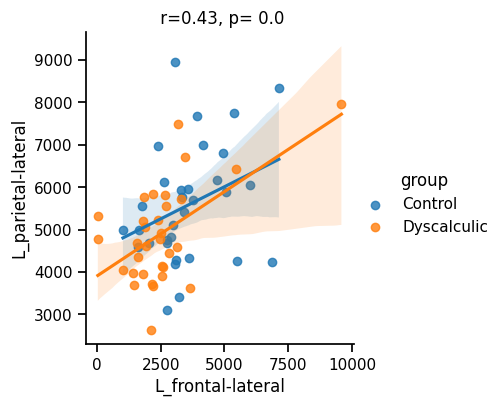

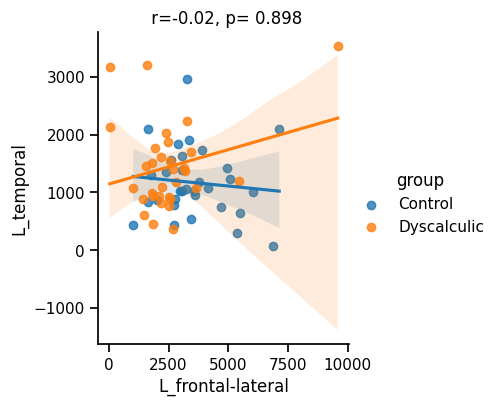

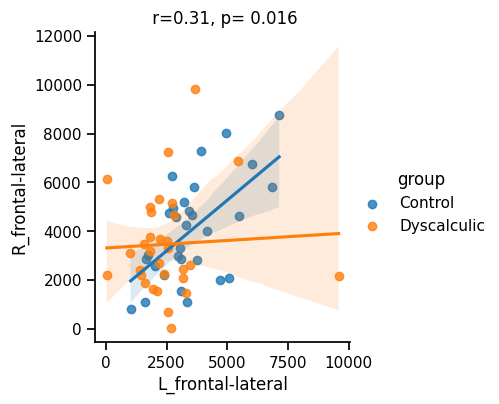

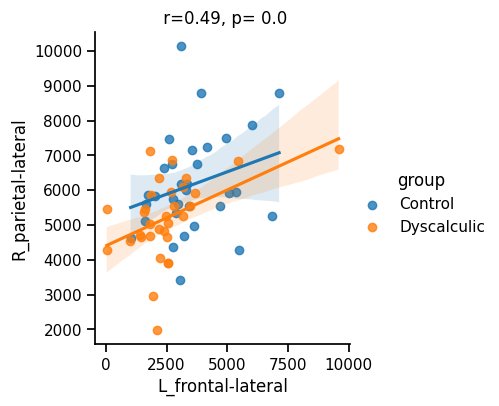

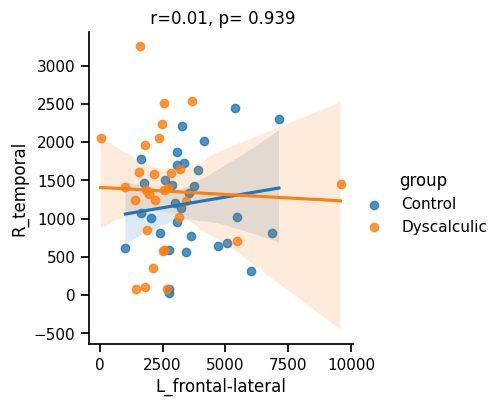

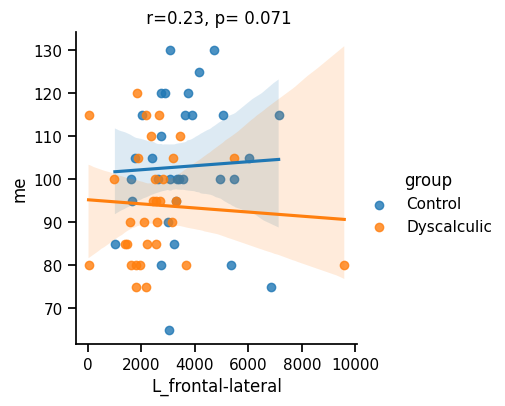

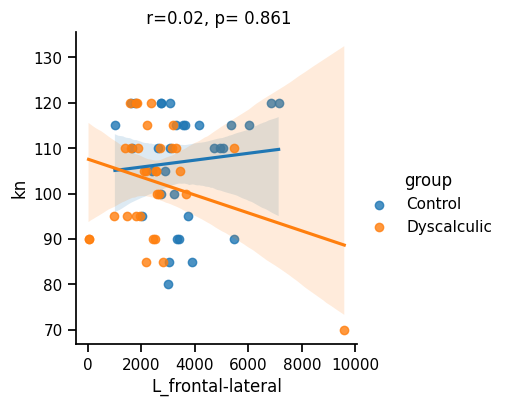

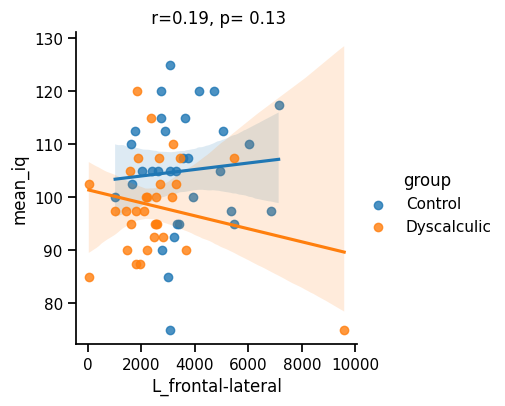

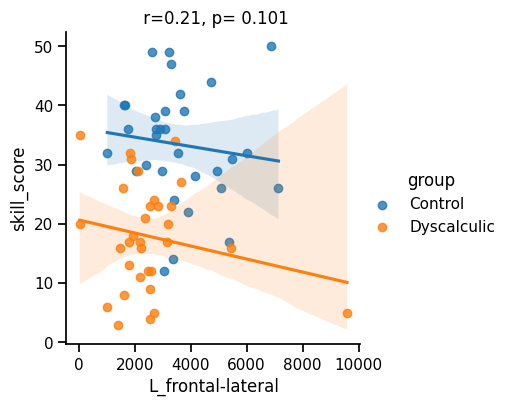

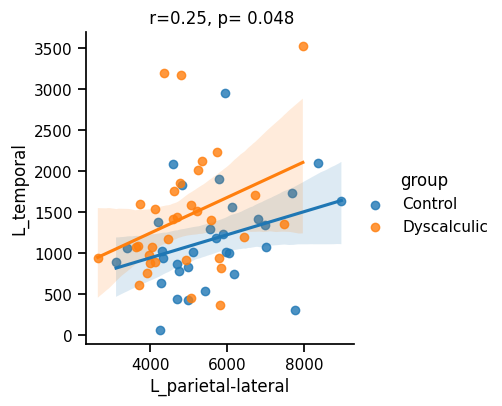

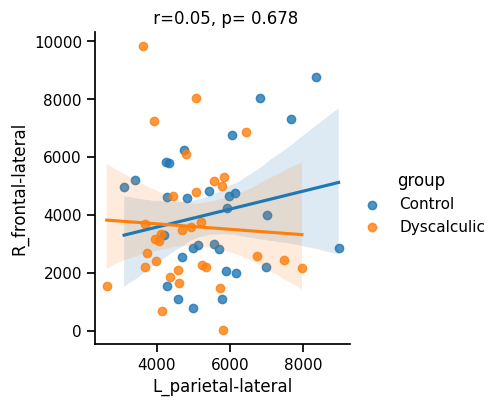

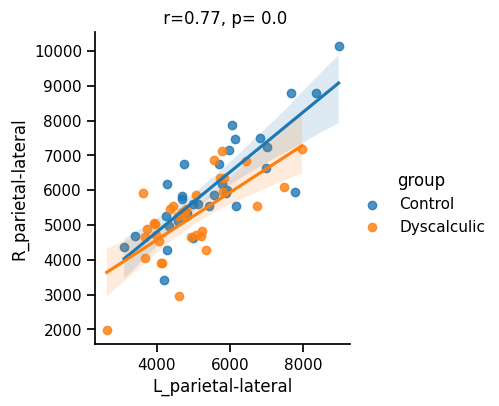

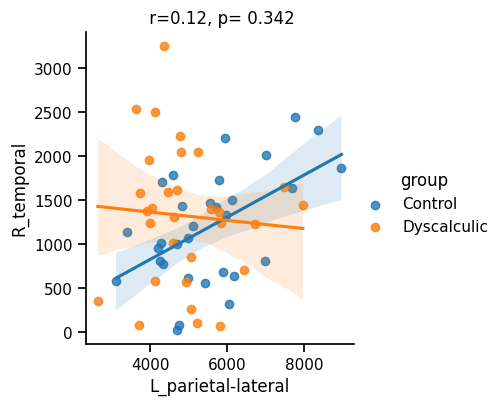

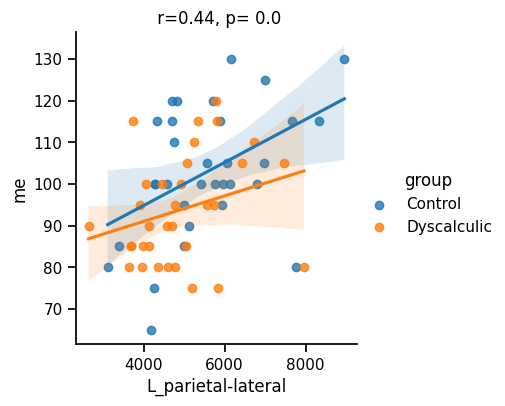

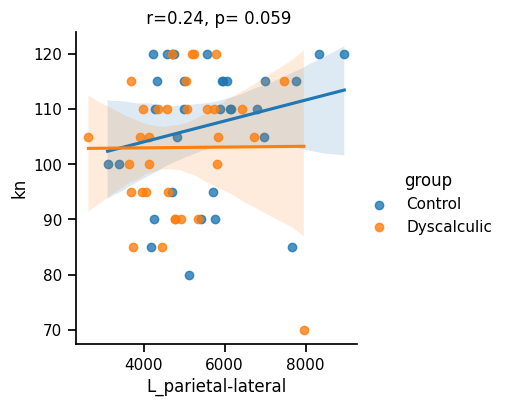

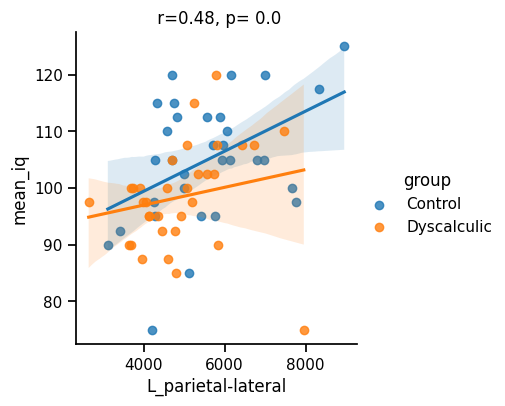

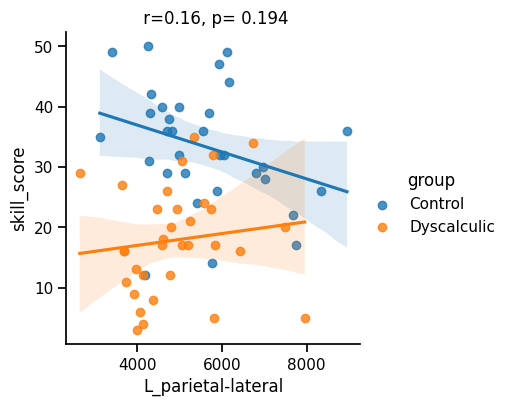

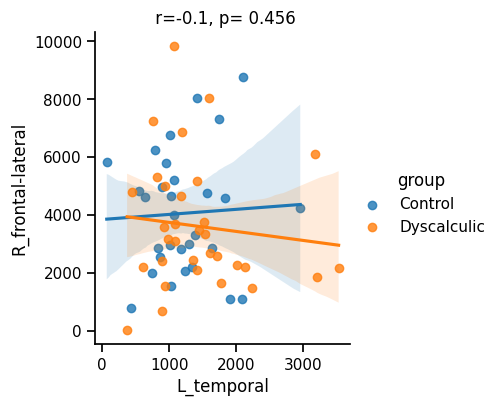

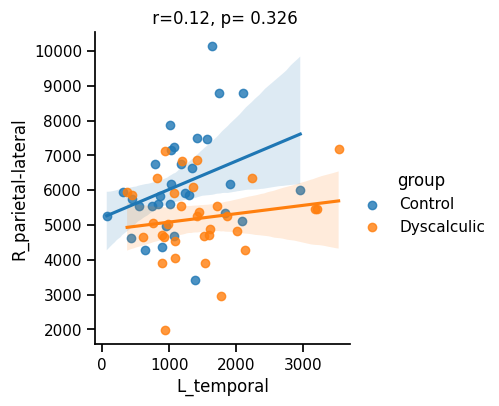

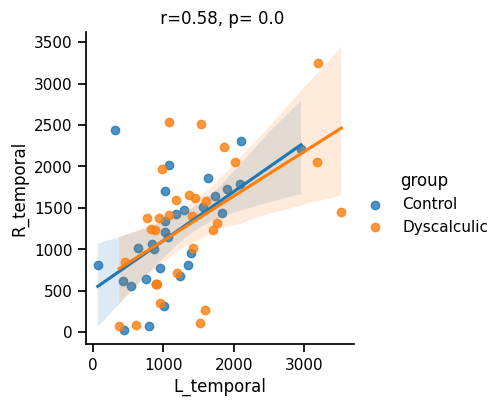

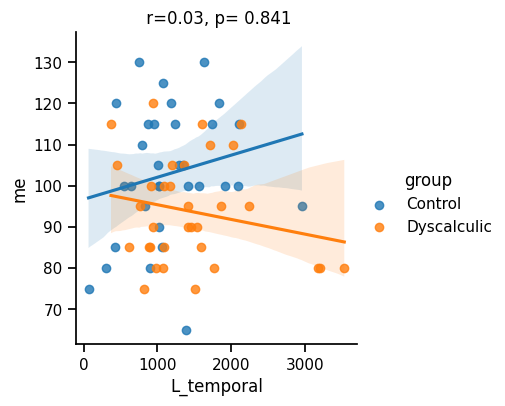

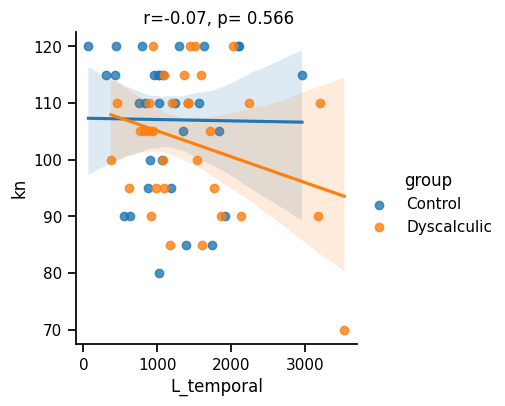

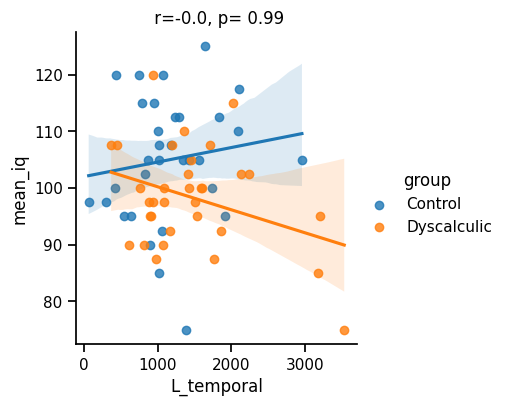

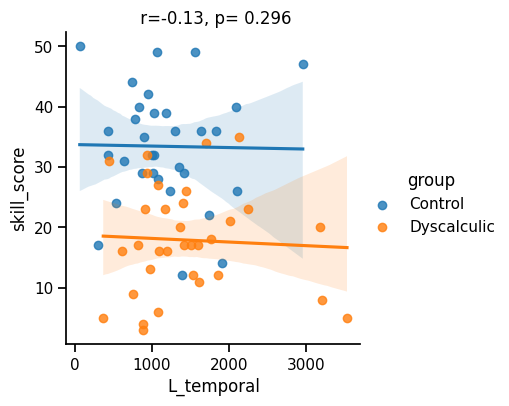

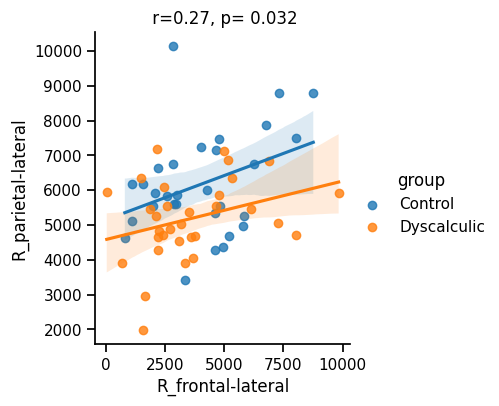

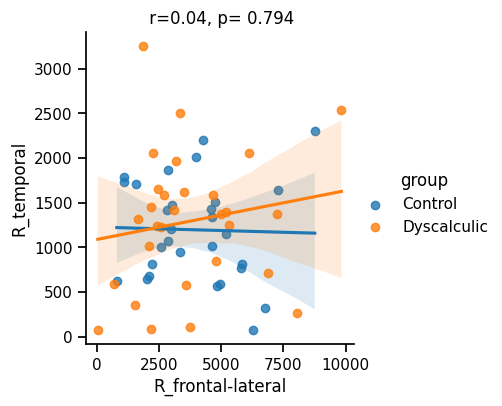

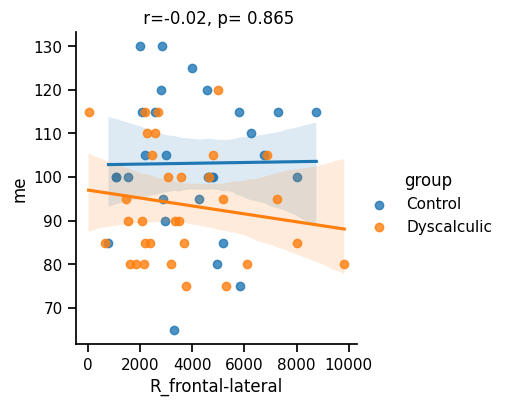

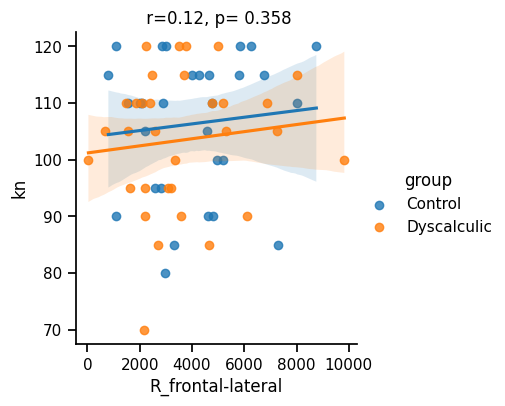

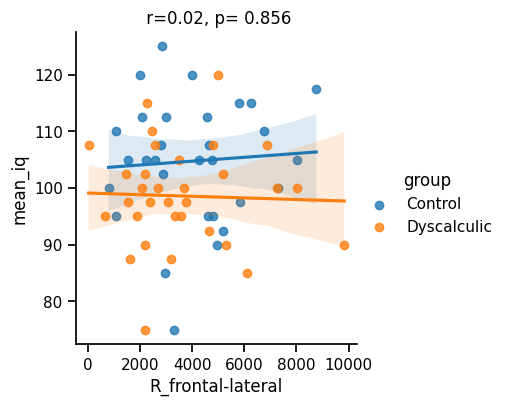

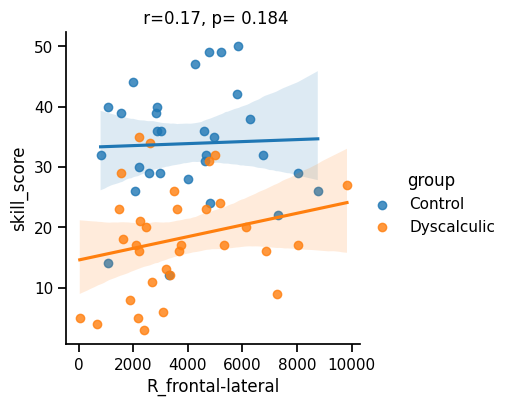

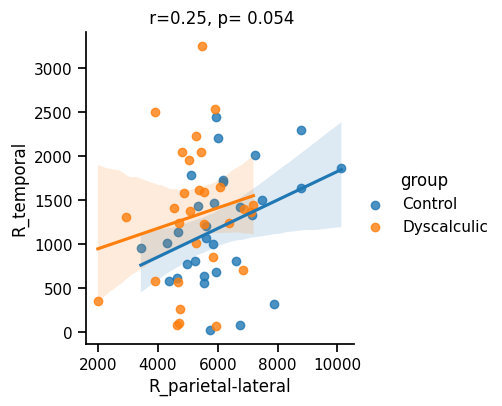

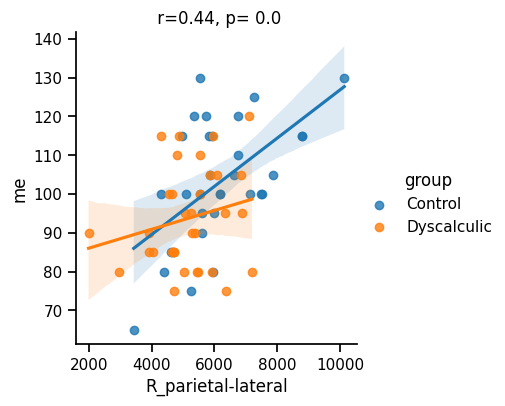

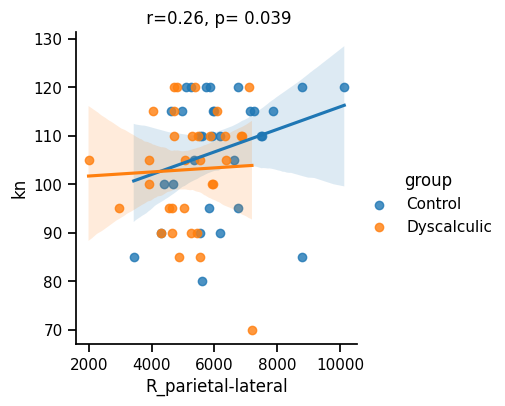

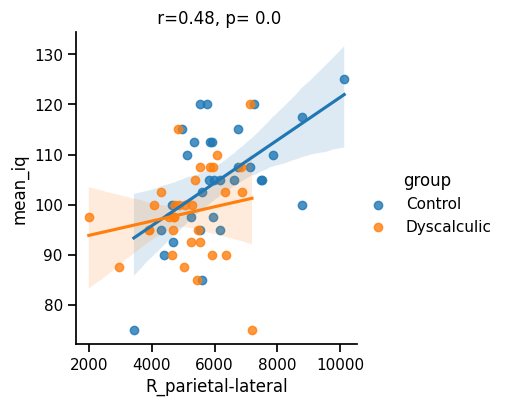

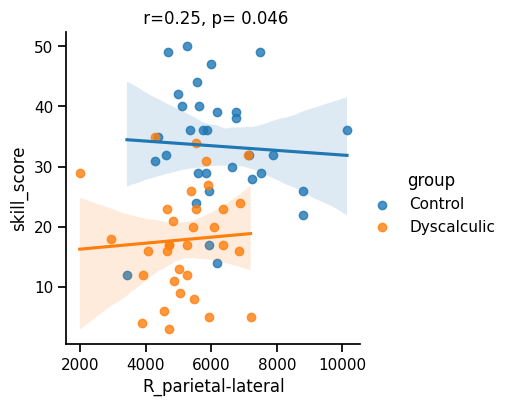

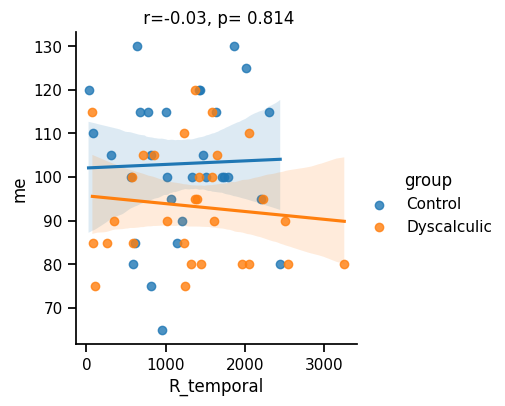

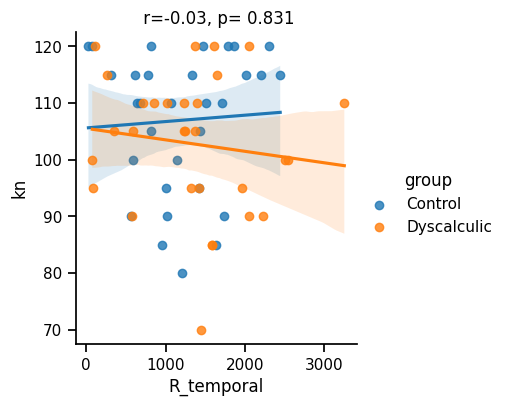

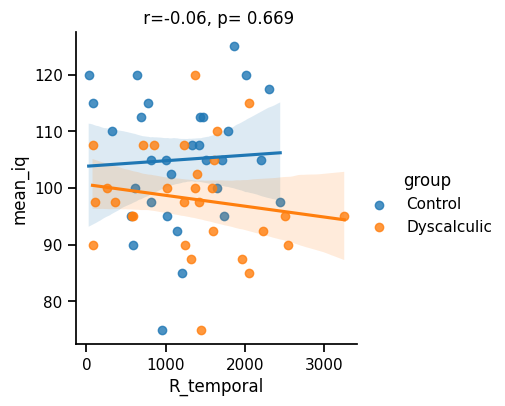

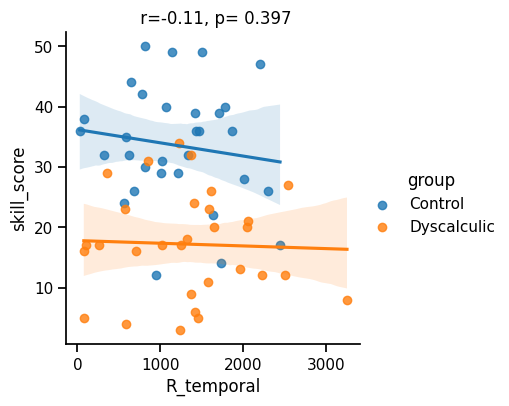

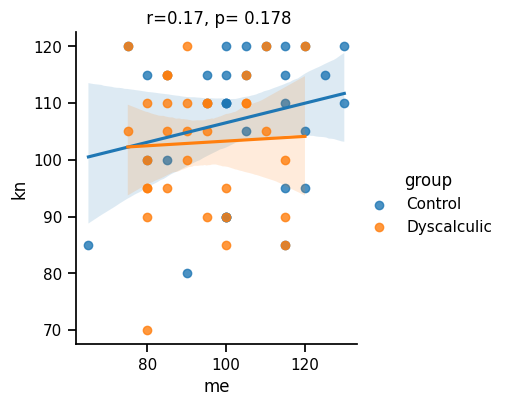

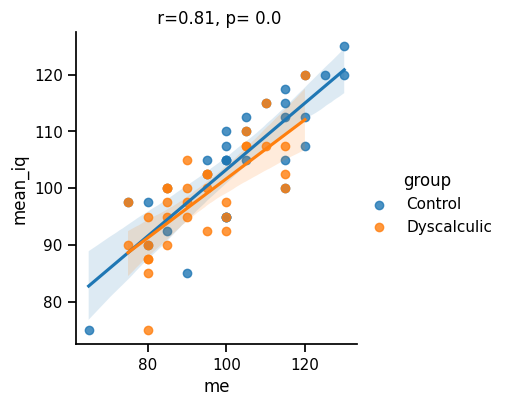

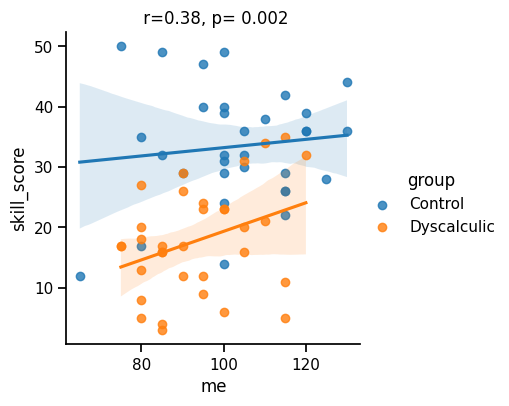

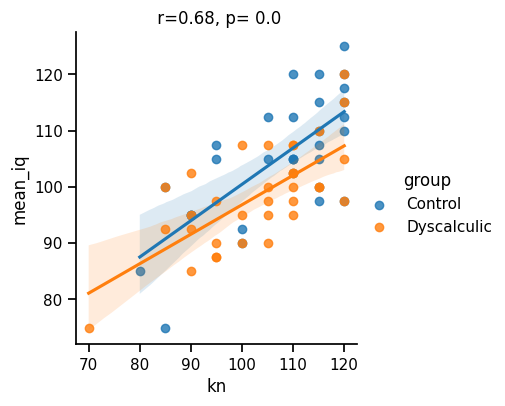

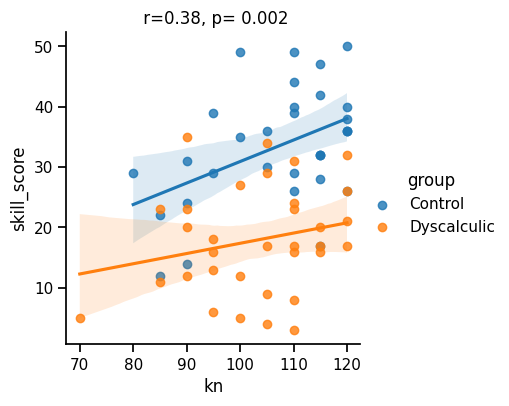

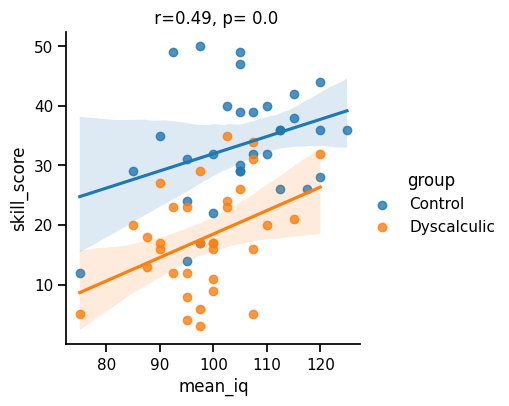

In [14]:

import itertools
import pingouin

sns.set_context('notebook')

vars = df_comb.columns.drop(['group'])

tmp = df_comb#.drop(labels=46,axis=0)

for x_var, y_var in itertools.combinations(vars, 2):
    cor = pingouin.corr(tmp[y_var], tmp [x_var], method = 'spearman') #defautl: two -sided & pearson
    r_ = np.round(cor['r'][0], 2)
    p = np.round(cor['p-val'][0], 3)
    #print(f'{x_var} vs {y_var}: r={r_}, p= {p}')
    fig = sns.lmplot(x=x_var, y=y_var, data=tmp, hue='group',height=4) #, hue='group' hue='group',
    fig.set(title=f' r={r_}, p= {p}') 